In [260]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from sklearn import linear_model
import seaborn as sns
import random 
import statistics 
import math 
import scipy as sc
from scipy.stats import chisquare
from collections import Counter

random.seed(42)

### Part 1: A discrete-time model

In this project, we will work with the following Markov model.
The model follows women after they had their breast tumor removed. The cancer may reappear close to the removed tumor. This is called local recur- rence, and the woman enters state 2. The cancer may also reappear distant from where it was operated. This is called distant metastatis. Both things may also occour. Death can occur from any state. In this model, once the death state has been entered, it can never be left again. This means the simulation should be terminated once this state has been reached.

### Task 1

Use the following probability matrix:

In [261]:
P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],
               [0, 0.986, 0.005, 0.004, 0.005],
               [0, 0, 0.992, 0.003, 0.005],
               [0, 0, 0, 0.991, 0.009],
               [0, 0, 0, 0, 1]])

Assume that one time step equals one month. Simulate 1000 women, all starting in state 1, until death. Summarize the lifetime distribution of the women, after surgery, for example using a histogram. In what proportion of women does the cancer eventually reappear, locally?

In this assignment we want to simulate 1000 women who have had breast cancer and have undergone surgery. There are 5 possible states they can get into after surgery.

• State 1: Healthy after removal of the tumor,

• State 2: Local recurrence of the cancer,

• State 3: Distant recurrence of the cancer,

• State 4: Both local and distant recurrence of the cancer,

• State 5: Death.

In [262]:
n_women = 1000
survival_distribution = []
cancer_local_count = 0
states = []

In [263]:
for _ in range(n_women):
    state = 0 
    survivaltime = 0
    had_local = False 

    while state != 4: 
        state = np.random.choice(range(5), p=P[state])
        survivaltime += 1

        if state == 1 or state == 3:  
            had_local = True
            
    if had_local:
        cancer_local_count += 1
        
    states.append(state)
    survival_distribution.append(survivaltime)

Text(0.5, 1.0, 'Lifetime Distribution of Women after Surgery')

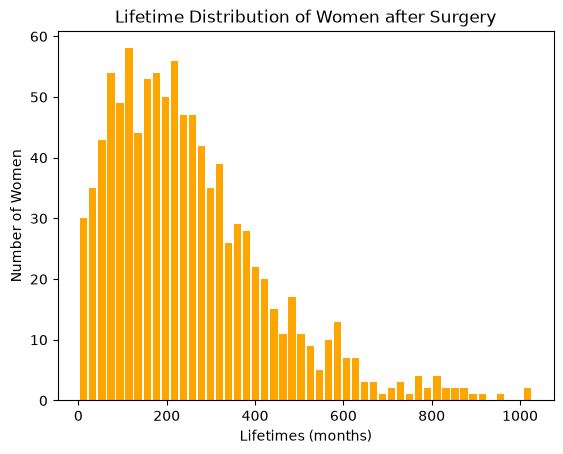

In [264]:
plt.hist(survival_distribution, bins=50, rwidth=0.8, color="orange")
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('Lifetime Distribution of Women after Surgery')

In [265]:
reapear_locally = cancer_local_count/n_women
print("Median of lifetime distribution of women after Surgery = ",np.median(survival_distribution) )
print("Proportion of women where cancer reapear locally = ", reapear_locally)


Median of lifetime distribution of women after Surgery =  218.0
Proportion of women where cancer reapear locally =  0.695


The histogram shows the distribution of how many months women survive after surgery. The plot is right skewed, meaning that most women survive shorter than the median. We can also conclude that the proportion of women where cancer reappears locally is approx. 70%.

#### Task 2
In your simulations, what is the distribution over the states at t = 120? Does this correspond to what we expect? Answer the question using an appropriate statistical test.

Using the probability distribution over the states at time t: $p_{t} = p_{t}(P^{0})$, we expect everyone to be in state 0 (Surgery) at first, as the experiment starts after surgery. We thereby define $p_{0} = [1, 0, 0, 0, 0]$

In [266]:
def time_state_distribution(n, t):
    survival_distribution = []
    states = []

    for _ in range(n):
        state = 0 
        survivaltime = 0

        while state != 4 and survivaltime < t: 
            state = np.random.choice(range(5), p=P[state])
            survivaltime += 1
            
        states.append(state)
        survival_distribution.append(survivaltime)
    
    return survival_distribution, states

In [267]:
t = 120
survival_time, n_states = time_state_distribution(n_women, t)

Text(0.5, 1.0, 'State')

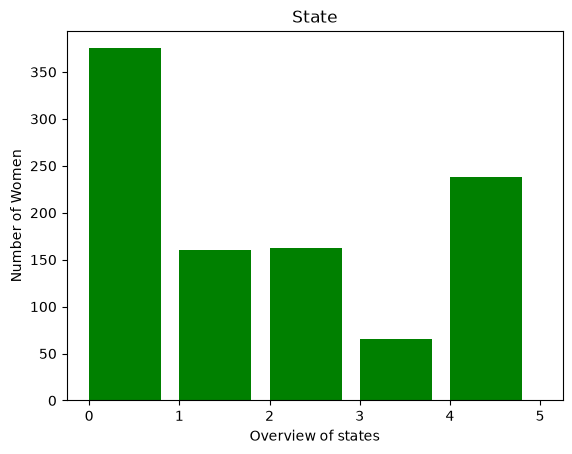

In [268]:
plt.hist(n_states, bins=range(len(P)+1), color="green",  width=0.8);
plt.xlabel('Overview of states')
plt.ylabel('Number of Women')
plt.title('State')

In [269]:
states_count = np.array(list(Counter(sorted(n_states)).values()))
observed = [float(x) / float(n_women) for x in states_count]

print("Observed probabilities per state =", observed)

Observed probabilities per state = [0.375, 0.16, 0.162, 0.065, 0.238]


We can conclude that it is most likely to be at state 1 (surgery) or 5 (Death).

We use the probability distribution over the states at time t: $p_{t} = p_{t}(P^{0})$ in order to find the expected probability distribution of states. We expect everyone to be in state 0 (Surgery) at first, as the experiment starts after surgery. We thereby define $p_{0} = [1, 0, 0, 0, 0]$

In [270]:
p_0 = np.array([1, 0, 0, 0, 0])
t = 120
p_t = np.dot(p_0, np.linalg.matrix_power(P, t))

print("Distribution over the states at t =", t,":")
print(p_t)

Distribution over the states at t = 120 :
[0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]


We can conclude that according to the theoretical it is most likely to be at state 1 (surgery) or 5 (death). The 2 highest are still states 1,  5 as in our simulated example, therefore the simulated and theoretical are very similar. There is no big fluctuation in our simulated and theoretical distribution as seen below

In [271]:
abs(p_t - observed)

array([0.01597373, 0.00104396, 0.0040869 , 0.00274149, 0.0101893 ])

We now use a $\chi^2$  test  as our statistical test performed by finding the test statistic using the following expression:
$T = \sum_{i=1}^{n_{classes}}\cfrac{(n_{observed,i}-n_{expected,i})^2}{n_{expected,i}}$
The statistic is to be evaluated with the distribution with df degrees of freedom. df is generally $n_{classes} − 1 − m$ where m is the number of estimated parameters.

After this then find the p-value using the  following expression:

$P(\chi^2_df ≥ T)$

In [272]:
expected_count = n_women * p_t


chi2_stat, chi2_pvalue = chisquare(states_count, expected_count)

print("Chi-square test-statistics =", chi2_stat)
print("Chi-square p-values =", chi2_pvalue)

Chi-square test-statistics = 1.347388182428923
Chi-square p-values = 0.8532856786599766


The p value > 0.05 means that we can accept the hypothesis that our simulated observed values follow the theoretical values.

#### Task 3
Does your simulated lifetimes follow this distribution?

In [273]:
t = 1000
survival_dist, n_states = time_state_distribution(n_women, t)

In [274]:
Ps = P[:4,:4]
ps = P[:-1, -1]
Ps, ps

(array([[0.9915, 0.005 , 0.0025, 0.    ],
        [0.    , 0.986 , 0.005 , 0.004 ],
        [0.    , 0.    , 0.992 , 0.003 ],
        [0.    , 0.    , 0.    , 0.991 ]]),
 array([0.001, 0.005, 0.005, 0.009]))

In [275]:
pi = np.array([1, 0, 0, 0])
I = np.eye(4)

P_T_Expected = []
E_T_Expected = np.dot(np.dot(pi, np.linalg.inv(I - Ps)), np.ones(4))

for i in range(t): 
    P_T_Expected.append(np.dot(np.dot(pi, np.linalg.matrix_power(Ps, i)), ps))



Text(0.5, 1.0, 'Lifetime Distribution of Women after Surgery')

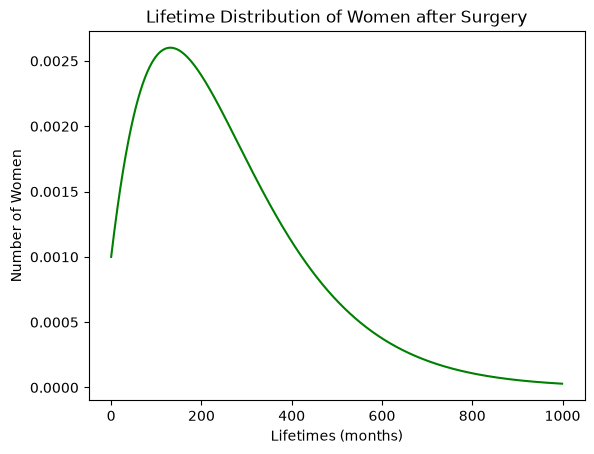

In [276]:
plt.plot(P_T_Expected, color="green")
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('Lifetime Distribution of Women after Surgery')

In [277]:
print("Simulated Mean Lifetime =", np.mean(survival_dist))
print("Theoretical Mean Lifetime =", E_T_Expected)

Simulated Mean Lifetime = 266.345
Theoretical Mean Lifetime = 262.3716153127931
